In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import svd

In [3]:
class Smoother(ABC):
    @abstractmethod
    def smooth(self, series: np.ndarray) -> np.ndarray:
        pass


class SSASmoother(Smoother):
    def __init__(self, window_length: int = 30, components_to_keep: int = 1):
        self.window_length = window_length
        self.components_to_keep = components_to_keep

    def _create_trajectory_matrix(self, series: np.ndarray) -> np.ndarray:
        n = len(series)
        k = n - self.window_length + 1
        return np.column_stack([
            series[i:i + k] for i in range(self.window_length)
        ])

    @staticmethod
    def _diagonal_averaging(matrix: np.ndarray) -> np.ndarray:
        l, k = matrix.shape
        n = l + k - 1
        result = np.zeros(n)
        counts = np.zeros(n)

        for i in range(l):
            for j in range(k):
                result[i + j] += matrix[i, j]
                counts[i + j] += 1

        return result / counts

    def smooth(self, series: np.ndarray) -> np.ndarray:
        n = len(series)
        if self.window_length < 2 or self.window_length > n / 2:
            raise ValueError("window_length must be in [2, N/2]")

        x = self._create_trajectory_matrix(series)
        u, s, vh = svd(x, full_matrices=False)

        x_approx = sum(
            s[i] * np.outer(u[:, i], vh[i, :])
            for i in range(self.components_to_keep)
        )
        return self._diagonal_averaging(x_approx)

In [4]:
class WaveletDecomposer:
    def __init__(self, level: int = 3):
        self.level = level
        self.low_pass_filter = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)])
        self.high_pass_filter = np.array([-1 / np.sqrt(2), 1 / np.sqrt(2)])

    @staticmethod
    def _convolve_down(signal: np.ndarray, filt: np.ndarray) -> np.ndarray:
        convolved = np.convolve(signal, filt[::-1], mode='full')
        return convolved[::2]

    @staticmethod
    def _convolve_up(signal: np.ndarray, filt: np.ndarray) -> np.ndarray:
        upsampled = np.zeros(len(signal) * 2)
        upsampled[::2] = signal
        return np.convolve(upsampled, filt, mode='full')

    def decompose(self, series: np.ndarray) -> list[np.ndarray]:
        coeffs = []
        current = series.copy()

        for _ in range(self.level):
            approx = self._convolve_down(current, self.low_pass_filter)
            detail = self._convolve_down(current, self.high_pass_filter)
            coeffs.append((approx, detail))
            current = approx

        return coeffs

    def reconstruct(self, coeffs: list[np.ndarray]) -> np.ndarray:
        current = coeffs[-1][0]

        for approx, detail in reversed(coeffs):
            approx_up = self._convolve_up(current, self.low_pass_filter)
            detail_up = self._convolve_up(detail, self.high_pass_filter)
            current = approx_up[:len(detail_up)] + detail_up

        return current[:len(coeffs[0][0]) * 2]

In [23]:
class ChangePointDetector(ABC):
    @abstractmethod
    def detect(self, series: np.ndarray) -> int:
        pass


class GraphicalChangePointDetector(ChangePointDetector):
    def __init__(self):
        self.s = None
        self.tau = None

    def detect(self, series: np.ndarray) -> int:
        mean = np.mean(series)
        self.s = np.cumsum(series - mean)
        self.tau = np.argmax(np.abs(self.s))
        return self.tau

    def plot(self, series: np.ndarray, times: Optional[np.ndarray] = None):
        if self.s is None:
            raise RuntimeError("Run detect() first.")

        if times is None:
            times = np.arange(len(series))

        plt.figure(figsize=(10, 4))
        plt.plot(times, self.s, label="CUSUM", color='blue')
        plt.axvline(times[self.tau], color='red', linestyle='--', label=f'Max deviation @ {self.tau}')
        plt.title("Graphical method: Cumulative Sum of Deviations")
        plt.xlabel("Time")
        plt.grid(True)
        plt.legend()
        plt.show()


class BrodskyDarkhovskyDetector(ChangePointDetector):
    def __init__(self, min_distance: int = 10):
        self.min_distance = min_distance

    def detect(self, series: np.ndarray) -> int:
        n = len(series)
        max_stat = -np.inf
        change_point = -1

        for tau in range(self.min_distance, n - self.min_distance):
            left_mean = np.mean(series[:tau])
            right_mean = np.mean(series[tau:])
            stat = abs(left_mean - right_mean)

            if stat > max_stat:
                max_stat = stat
                change_point = tau

        return change_point

In [10]:
@dataclass
class TimeSeries:
    file_path: str
    series_col_name: str
    time_col_name: str
    time_format: str
    dataset: Optional[pd.DataFrame] = None

    def __post_init__(self):
        self.dataset = self._load_time_series()

    @property
    def series(self) -> pd.Series:
        return self.dataset[self.series_col_name]

    @property
    def times(self) -> pd.Series:
        return self.dataset[self.time_col_name]

    def _load_time_series(self) -> pd.DataFrame:
        if self.file_path.endswith('.csv'):
            return (
                pd.read_csv(self.file_path, parse_dates=[self.time_col_name])
                .assign(**{
                    self.time_col_name: lambda d: pd.to_datetime(
                        d[self.time_col_name], format=self.time_format
                    )
                })
                .sort_values(by=self.time_col_name)
            )
        raise TypeError(
            f"Unexpected file format: {self.file_path.split('.')[-1]}."
        )

    def plot_series(
            self,
            series: Optional[np.ndarray] = None,
            times: Optional[np.ndarray] = None,
            label: Optional[str] = None,
            changepoint: Optional[int] = None
    ) -> None:
        series = series if series is not None else self.series.to_numpy()
        times = times if times is not None else self.times.to_numpy()

        min_len = min(len(series), len(times))
        series, times = series[:min_len], times[:min_len]

        plt.plot(times, series, label=label or "Series")
        if changepoint is not None:
            plt.axvline(times[changepoint], color='red',
                        linestyle='--', label=f'Change @ {changepoint}')
        plt.xlabel("Time")
        plt.ylabel("Series")
        plt.grid(True)
        if label or changepoint is not None:
            plt.legend()
        plt.show()

    def smooth(self, smoother: Smoother) -> np.ndarray:
        return smoother.smooth(self.series)

    def decompose(self, decomposer: WaveletDecomposer) -> list[np.ndarray]:
        return decomposer.decompose(self.series)

    def process(self, smoother: Smoother, decomposer: WaveletDecomposer) -> list[np.ndarray]:
        smoothed = self.smooth(smoother)
        coeffs = decomposer.decompose(smoothed)
        return decomposer.reconstruct(coeffs)

    def detect_changepoint(self, detector: ChangePointDetector, series: Optional[np.ndarray] = None) -> int:
        series = series if series is not None else self.series
        return detector.detect(series)

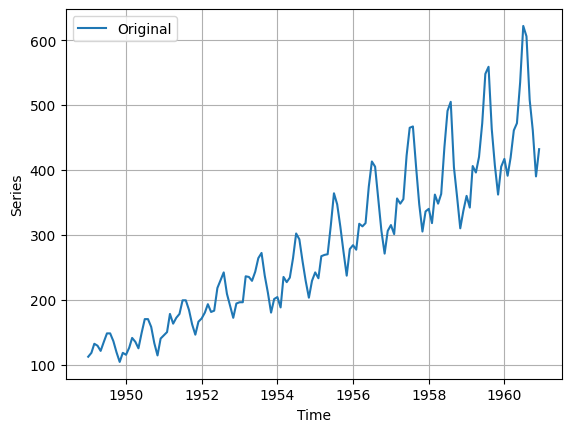

In [11]:
ts = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
ts.plot_series(label="Original")

# Smoothing

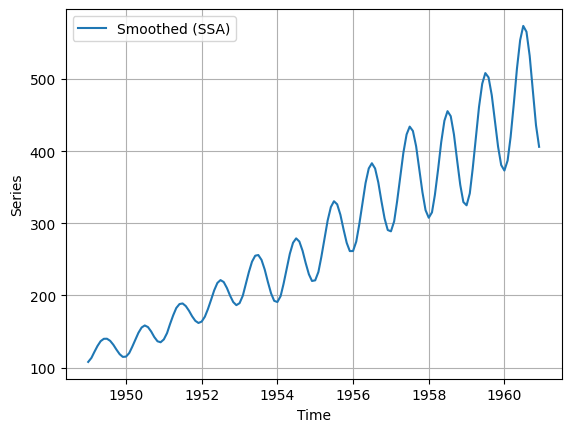

In [64]:
ssa = SSASmoother(window_length=12, components_to_keep=3)
smoothed = ts.smooth(ssa)
ts.plot_series(series=smoothed, label="Smoothed (SSA)")

# Wavelet decompose

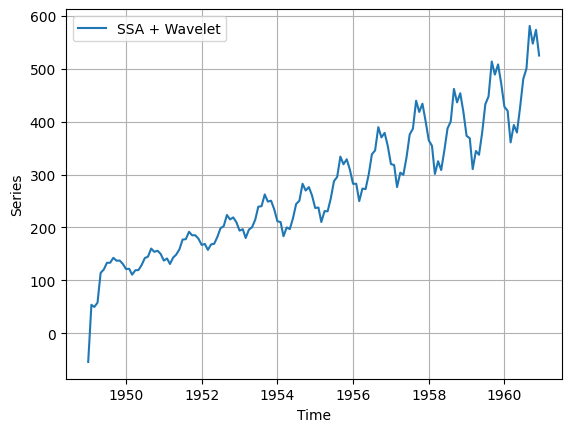

In [78]:
wavelet = WaveletDecomposer(level=2)
processed = ts.process(ssa, wavelet)
ts.plot_series(series=processed, label="SSA + Wavelet")

# Theft detection algorithms

## Grahical Change Point

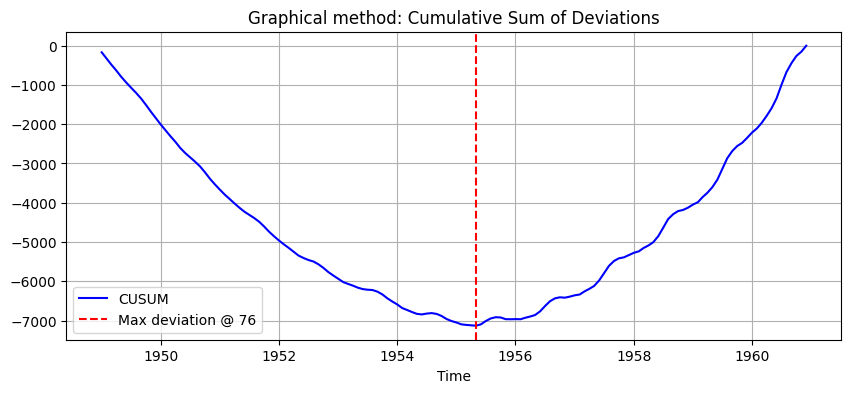

In [24]:
graphical = GraphicalChangePointDetector()

tau = graphical.detect(ts.series)
graphical.plot(ts.series, ts.times)

## Brodsky-Darkhovsky Detector

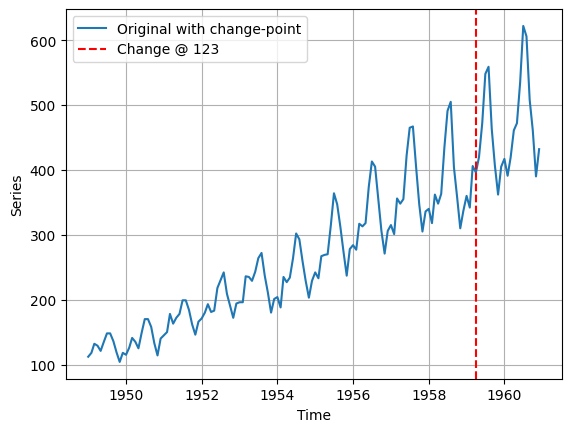

In [22]:
detector = BrodskyDarkhovskyDetector(min_distance=20)
tau = ts.detect_changepoint(detector)
ts.plot_series(changepoint=tau, label="Original with change-point")